# Trực quan hóa dữ liệu bất động sản Zillow (EDA Visualization)

File này kế thừa các phát hiện từ `data_analyze.ipynb` và chuyển hóa thành hình ảnh trực quan:

1. Phân phối biến mục tiêu `price` (Histogram + KDE)
2. Ma trận nhiệt tương quan (Correlation Heatmap)
3. Quan hệ `living` vs `price` (Scatter Plot)
4. Bản đồ phân bố địa lý theo `price` (Geographic Plot)
5. So sánh đặc trưng phân loại: thị phần loại nhà (Bar Plot) & phân tán giá theo loại nhà (Boxplot)


## 0. Import thư viện & đọc dữ liệu

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='viridis')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

df = pd.read_csv('zillow_final.csv')
df = df.drop_duplicates().reset_index(drop=True)

# Gộp các cột one-hot loại nhà thành 1 cột nhãn 'house_type' để dùng cho các biểu đồ phân loại
type_cols = ['type_single', 'type_condo', 'type_manufactured', 'type_multi', 'type_townhouse']

def get_house_type(row):
    for col in type_cols:
        if row[col]:
            return col.replace('type_', '')
    return 'unknown'

df['house_type'] = df[type_cols].apply(get_house_type, axis=1)

print(f"Dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")
df.head()


Dữ liệu: 4251 dòng, 33 cột


,price,bed,bath,living,lot_sqft,lot_living,bed_bath,type_condo,type_manufactured,type_multi,...,risk_loss,risk_social,risk_resilience,risk_fire,risk_earthquake,risk_heat,dist_city,dist_airport,dist_coast,house_type
0,4980000.0,4.0,5.0,4126.0,4922.000,1.192923,0.8,False,False,False,...,89.710407,9.209856,12.692809,73.920540,94.138632,8.354783,13.715619,17.888756,13.623171,single
1,1215000.0,3.0,2.0,1825.0,7840.800,4.296329,1.5,False,False,False,...,83.604998,23.062252,12.692809,18.467649,89.615069,13.904381,39.379252,34.192540,22.666476,single
2,2629000.0,4.0,4.0,3019.0,43381.404,14.369461,1.0,False,False,False,...,96.534514,9.209856,12.692809,98.160370,93.614213,13.158396,18.768005,19.185657,11.646300,single
3,400000.0,3.0,2.0,944.0,4268.880,4.522119,1.5,False,False,True,...,43.952134,93.082983,12.692809,0.000000,93.975717,20.717146,9.473542,11.193127,18.586372,multi
4,849000.0,2.0,2.0,1154.0,5002.000,4.334489,1.0,False,False,False,...,54.870000,40.578096,12.692809,0.000000,87.909814,8.907717,37.911992,27.545766,35.124601,single


## 1. Trực quan hóa phân phối biến mục tiêu `price`

Vẽ Histogram kết hợp đường cong mật độ (KDE) để làm nổi bật hiện tượng **lệch phải (right-skewed)** và các giá trị ngoại lai của giá nhà. Biểu đồ được vẽ ở cả 2 trục: tỷ lệ gốc và log-scale để nhìn rõ hơn phần đuôi phân phối.

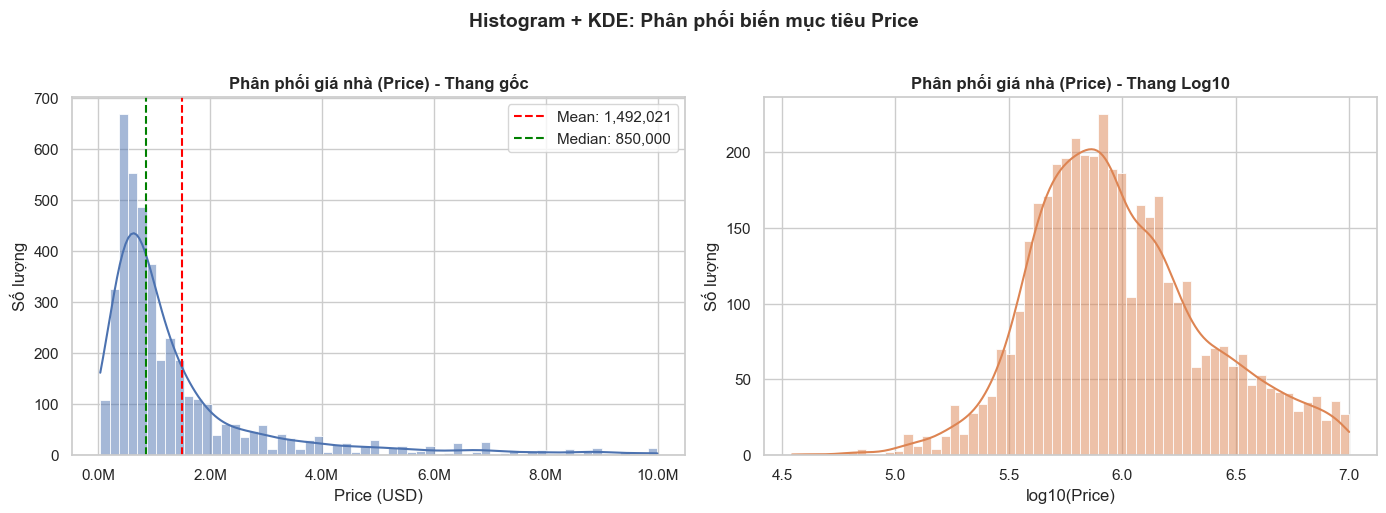

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Biểu đồ 1: Phân phối giá gốc ---
sns.histplot(df['price'], bins=60, kde=True, color='#4C72B0', ax=axes[0])
axes[0].axvline(df['price'].mean(), color='red', linestyle='--', linewidth=1.5, label=f"Mean: {df['price'].mean():,.0f}")
axes[0].axvline(df['price'].median(), color='green', linestyle='--', linewidth=1.5, label=f"Median: {df['price'].median():,.0f}")
axes[0].set_title('Phân phối giá nhà (Price) - Thang gốc', fontweight='bold')
axes[0].set_xlabel('Price (USD)')
axes[0].set_ylabel('Số lượng')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].legend()

# --- Biểu đồ 2: Phân phối giá (log scale) để thấy rõ đuôi phân phối ---
log_price = np.log10(df['price'])
sns.histplot(log_price, bins=60, kde=True, color='#DD8452', ax=axes[1])
axes[1].set_title('Phân phối giá nhà (Price) - Thang Log10', fontweight='bold')
axes[1].set_xlabel('log10(Price)')
axes[1].set_ylabel('Số lượng')

plt.suptitle('Histogram + KDE: Phân phối biến mục tiêu Price', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Nhận xét:**
- Ở thang gốc, phân phối `price` **lệch phải rõ rệt**: phần lớn nhà tập trung ở khoảng giá thấp/trung bình, trong khi một số ít căn nhà có giá rất cao kéo dài đuôi phân phối sang phải — đây chính là các **outliers**.
- Đường Mean nằm bên phải đường Median, xác nhận lại hiện tượng lệch phải đã phát hiện ở file phân tích số liệu.
- Khi chuyển sang thang log10, phân phối gần với dạng chuẩn (bell-shaped) hơn, cho thấy `price` có bản chất phân phối dạng log-normal — gợi ý nên áp dụng phép biến đổi log khi xây dựng mô hình dự đoán giá.

## 2. Ma trận nhiệt tương quan (Correlation Heatmap)

Thể hiện độ tương quan giữa các nhóm đặc trưng: **cấu trúc** (`living`, `bed`, `bath`), **kinh tế** (`income`, `poverty`) và **khoảng cách** (`dist_coast`, `dist_city`) với `price`.

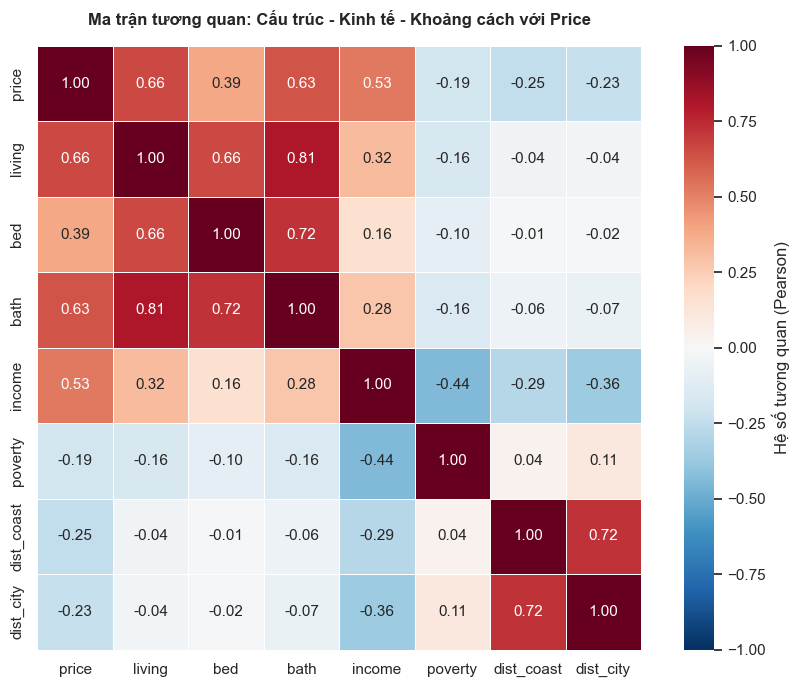

In [4]:
selected_features = ['price', 'living', 'bed', 'bath', 'income', 'poverty', 'dist_coast', 'dist_city']

corr_selected = df[selected_features].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_selected,
    annot=True, fmt='.2f',
    cmap='RdBu_r', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, square=True,
    cbar_kws={'label': 'Hệ số tương quan (Pearson)'}
)
plt.title('Ma trận tương quan: Cấu trúc - Kinh tế - Khoảng cách với Price', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


**Nhận xét:**
- Nhóm biến **cấu trúc** (`living`, `bath`, `bed`) có tương quan dương khá mạnh với `price`, trong đó `living` (diện tích sử dụng) là mạnh nhất — phù hợp với logic thị trường bất động sản.
- Nhóm biến **kinh tế**: `income` tương quan dương với `price` (khu vực thu nhập cao → giá nhà cao hơn), trong khi `poverty` có xu hướng tương quan âm.
- Nhóm biến **khoảng cách**: `dist_coast` và `dist_city` thường có tương quan âm nhẹ với `price` — nhà càng gần biển/trung tâm thành phố thường có xu hướng giá cao hơn.
- Ma trận cũng cho thấy các nhóm biến trong cùng phạm trù (ví dụ `bed` và `bath`, hoặc `dist_coast` và `dist_city`) có tương quan với nhau, cần lưu ý hiện tượng đa cộng tuyến (multicollinearity) nếu đưa vào mô hình hồi quy.

## 3. Phân tích mối quan hệ tuyến tính/phi tuyến: `living` vs `price`

Biểu đồ phân tán giữa diện tích sử dụng (`living`) và giá nhà (`price`) để quan sát xu hướng biến động và mật độ phân bố của các phân khúc nhà.

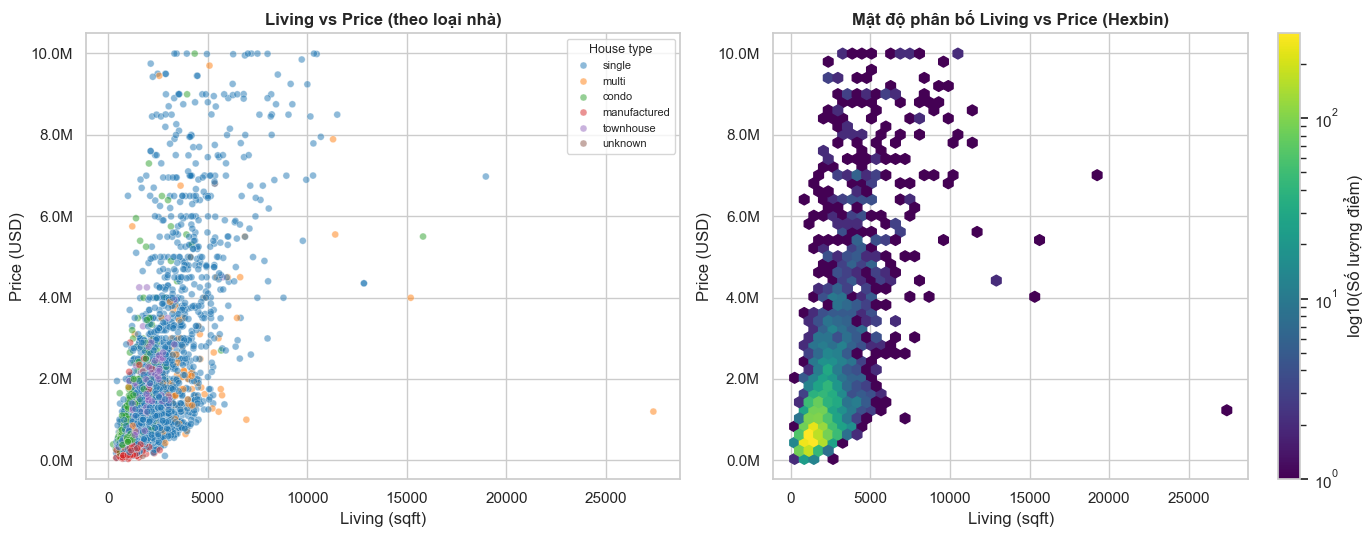

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Scatter thường, tô màu theo loại nhà ---
sns.scatterplot(
    data=df, x='living', y='price', hue='house_type',
    alpha=0.5, s=25, ax=axes[0], palette='tab10'
)
axes[0].set_title('Living vs Price (theo loại nhà)', fontweight='bold')
axes[0].set_xlabel('Living (sqft)')
axes[0].set_ylabel('Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
axes[0].legend(title='House type', fontsize=8, title_fontsize=9)

# --- Scatter với mật độ điểm (hexbin) để thấy rõ vùng tập trung dữ liệu ---
hb = axes[1].hexbin(df['living'], df['price'], gridsize=45, cmap='viridis', mincnt=1, bins='log')
axes[1].set_title('Mật độ phân bố Living vs Price (Hexbin)', fontweight='bold')
axes[1].set_xlabel('Living (sqft)')
axes[1].set_ylabel('Price (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
cb = plt.colorbar(hb, ax=axes[1])
cb.set_label('log10(Số lượng điểm)')

plt.tight_layout()
plt.show()


In [6]:
corr_living_price = df['living'].corr(df['price'])
print(f"Hệ số tương quan Pearson giữa living và price: {corr_living_price:.3f}")


Hệ số tương quan Pearson giữa living và price: 0.663


**Nhận xét:**
- Có xu hướng **tương quan dương rõ rệt** giữa `living` và `price`: nhà có diện tích sử dụng lớn hơn thường có giá cao hơn, tuy nhiên mối quan hệ có dấu hiệu **phi tuyến** — độ dốc tăng nhanh hơn ở phân khúc diện tích lớn (một số nhà rộng có giá tăng vọt bất thường, đây là các outliers/nhà cao cấp).
- Biểu đồ hexbin cho thấy phần lớn dữ liệu (mật độ điểm cao nhất) tập trung ở vùng diện tích nhỏ-trung bình và mức giá thấp-trung bình, trong khi các điểm ở vùng diện tích lớn/giá cao rất thưa thớt — xác nhận thêm hiện tượng lệch phải của `price`.
- Nhóm `single` (nhà riêng) có xu hướng trải rộng ở cả diện tích lớn và giá cao hơn hẳn so với các loại hình còn lại như `condo` hay `townhouse`.

## 4. Bản đồ phân bố địa lý (Geographic Plot)

Sử dụng `long` (kinh độ) và `lat` (vĩ độ) làm trục tọa độ, kết hợp thang màu đại diện cho `price` để trực quan hóa các khu vực đắt đỏ nhất tại California.

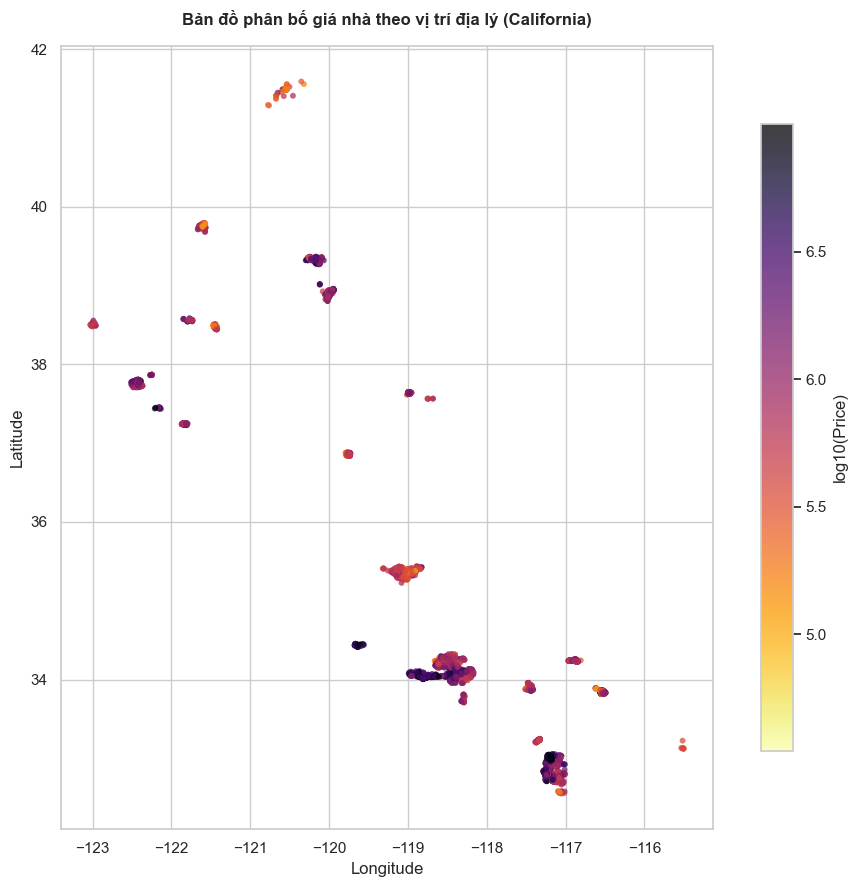

In [8]:
fig, ax = plt.subplots(figsize=(10, 9))

# Dùng log10(price) cho thang màu để giảm ảnh hưởng của outliers cực đoan, giúp thấy rõ khác biệt vùng
sc = ax.scatter(
    df['long'], df['lat'],
    c=np.log10(df['price']),
    cmap='inferno_r',
    s=18, alpha=0.75,
    edgecolors='none'
)

cb = plt.colorbar(sc, ax=ax, shrink=0.8)
cb.set_label('log10(Price)')

ax.set_title('Bản đồ phân bố giá nhà theo vị trí địa lý (California)', fontweight='bold', pad=15)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()


**Nhận xét:**
- Bản đồ nhiệt cho thấy giá nhà phân bố **không đồng đều theo không gian địa lý**: một số cụm khu vực (thường gần vùng ven biển hoặc các đô thị lớn) có màu đậm hơn — thể hiện mức giá cao hơn rõ rệt so với các khu vực còn lại.
- Đây là bằng chứng trực quan củng cố cho tương quan âm giữa `dist_coast`/`dist_city` và `price` đã thấy ở phần Heatmap: càng gần biển/trung tâm thành phố, giá nhà có xu hướng càng cao.
- Kết quả này gợi ý rằng vị trí địa lý (`lat`, `long`) là một yếu tố quan trọng, có thể cân nhắc mã hóa thành đặc trưng vùng (region/cluster) trong các bước phân tích hoặc mô hình hóa sâu hơn.

## 5. So sánh đặc trưng phân loại theo loại hình nhà

- **Bar Plot**: thị phần số lượng các loại nhà.
- **Boxplot**: so sánh sự phân tán giá nhà giữa các loại hình bất động sản.

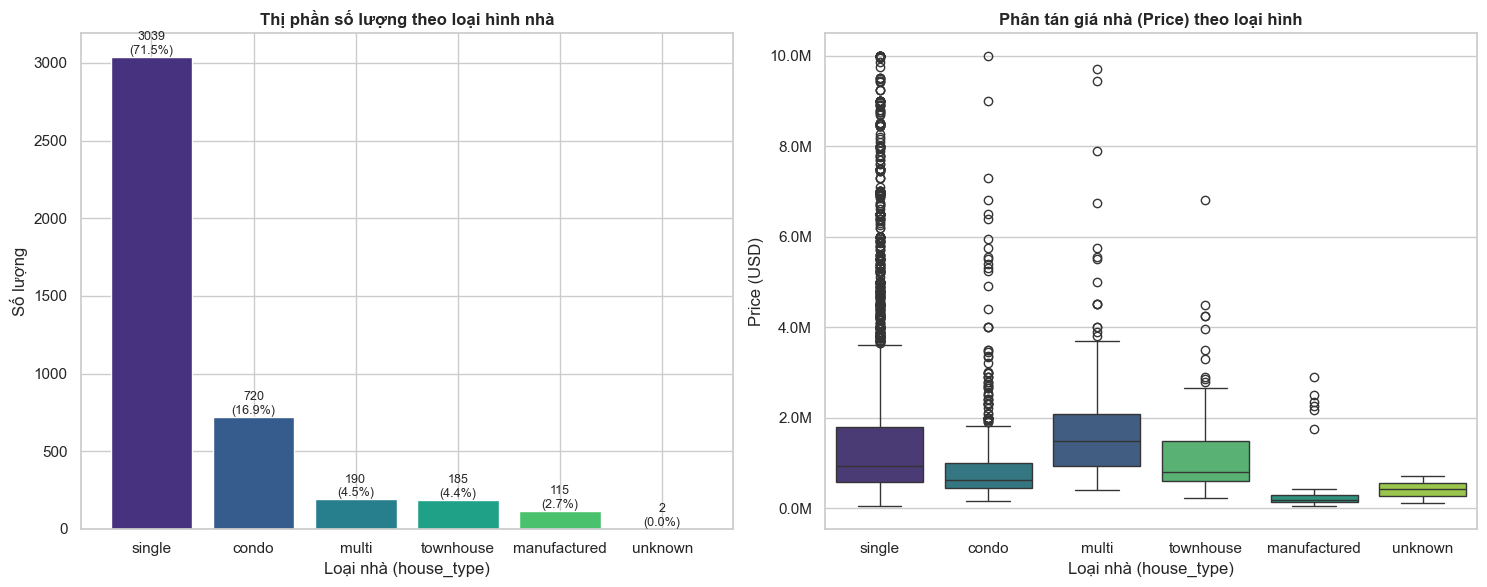

In [9]:
house_type_order = df['house_type'].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Bar Plot: thị phần số lượng ---
counts = df['house_type'].value_counts()
pct = (counts / counts.sum() * 100).round(1)

bars = axes[0].bar(counts.index, counts.values, color=sns.color_palette('viridis', len(counts)))
axes[0].set_title('Thị phần số lượng theo loại hình nhà', fontweight='bold')
axes[0].set_xlabel('Loại nhà (house_type)')
axes[0].set_ylabel('Số lượng')
for bar, c, p in zip(bars, counts.values, pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{c}\n({p}%)',
                 ha='center', va='bottom', fontsize=9)

# --- Boxplot: phân tán giá theo loại nhà ---
sns.boxplot(
    data=df, x='house_type', y='price',
    order=house_type_order, hue='house_type', legend=False,
    palette='viridis', ax=axes[1]
)
axes[1].set_title('Phân tán giá nhà (Price) theo loại hình', fontweight='bold')
axes[1].set_xlabel('Loại nhà (house_type)')
axes[1].set_ylabel('Price (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

plt.tight_layout()
plt.show()


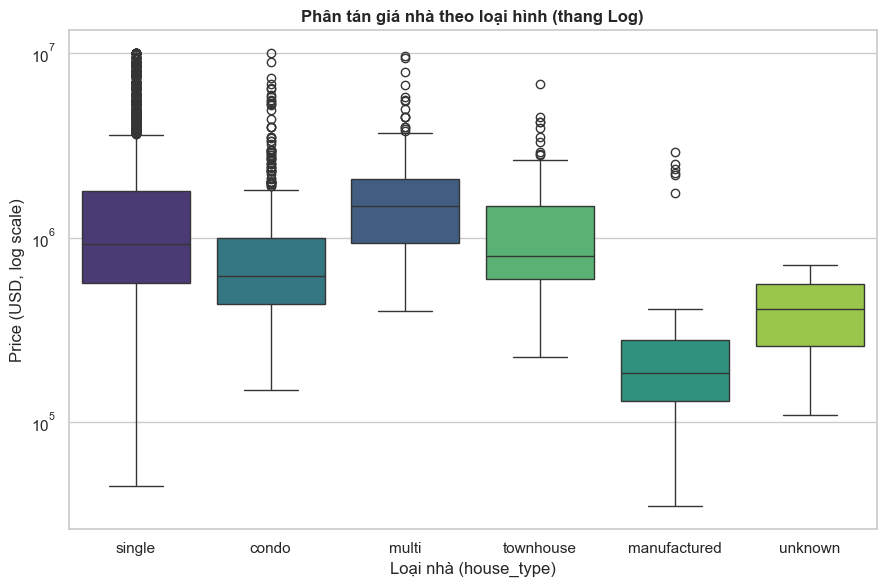

In [10]:
# Boxplot phiên bản log-scale để so sánh rõ hơn median/IQR khi price bị lệch mạnh bởi outliers
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df, x='house_type', y='price',
    order=house_type_order, hue='house_type', legend=False,
    palette='viridis'
)
plt.yscale('log')
plt.title('Phân tán giá nhà theo loại hình (thang Log)', fontweight='bold')
plt.xlabel('Loại nhà (house_type)')
plt.ylabel('Price (USD, log scale)')
plt.tight_layout()
plt.show()


**Nhận xét:**
- **Bar Plot** cho thấy loại hình `single` (nhà riêng) chiếm thị phần số lượng lớn nhất trong bộ dữ liệu, tiếp theo là các loại hình còn lại với tỷ trọng nhỏ hơn nhiều.
- **Boxplot** (thang gốc) bị chi phối mạnh bởi các outliers giá cao, khiến hộp (box) của nhiều loại nhà trông "dẹt" — đây chính là lý do cần xem thêm bản **thang log**.
- Ở thang log, có thể thấy rõ hơn: median giá của `single` cao hơn hẳn so với các loại còn lại như `condo`, `manufactured`; đồng thời độ phân tán (IQR) của `single` và `multi` cũng lớn hơn, cho thấy mức độ đa dạng về giá trong các phân khúc này cao hơn.
- Kết quả này phù hợp với phát hiện ở file phân tích số liệu: phân khúc **single-family** là phân khúc đắt giá nhất và cũng có độ biến động giá lớn nhất.

## 6. Trực quan hóa phân khúc giá và yếu tố khu vực

Các biểu đồ dưới đây bổ sung góc nhìn theo phân khúc giá, khoảng cách tới biển và nhóm thu nhập. Đây là phần giúp EDA chuyển từ mô tả tổng quan sang phân tích có giả thuyết rõ hơn.

In [ ]:
price_bins = [0, 500_000, 1_000_000, 2_000_000, np.inf]
price_labels = ['<500k', '500k-1M', '1M-2M', '>2M']

df['price_segment'] = pd.cut(df['price'], bins=price_bins, labels=price_labels, include_lowest=True)
df['coast_distance_group'] = pd.cut(
    df['dist_coast'],
    bins=[0, 10, 25, 75, np.inf],
    labels=['Near coast', 'Medium distance', 'Far from coast', 'Very far from coast'],
    include_lowest=True
)
df['income_quartile'] = pd.qcut(df['income'], q=4, labels=['Q1 income', 'Q2 income', 'Q3 income', 'Q4 income'])

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='price_segment', order=price_labels, ax=axes[0, 0], color='#4C72B0')
axes[0, 0].set_title('Số lượng nhà theo phân khúc giá', fontweight='bold')
axes[0, 0].set_xlabel('Price segment')
axes[0, 0].set_ylabel('Count')

segment_median = df.groupby('price_segment', observed=True)['price'].median().reindex(price_labels).reset_index()
sns.barplot(data=segment_median, x='price_segment', y='price', ax=axes[0, 1], color='#55A868')
axes[0, 1].set_title('Median price theo phân khúc giá', fontweight='bold')
axes[0, 1].set_xlabel('Price segment')
axes[0, 1].set_ylabel('Median price')

coast_order = ['Near coast', 'Medium distance', 'Far from coast', 'Very far from coast']
coast_median = df.groupby('coast_distance_group', observed=True)['price'].median().reindex(coast_order).reset_index()
sns.barplot(data=coast_median, x='coast_distance_group', y='price', ax=axes[1, 0], color='#C44E52')
axes[1, 0].set_title('Median price theo khoảng cách tới biển', fontweight='bold')
axes[1, 0].set_xlabel('Coast distance group')
axes[1, 0].set_ylabel('Median price')
axes[1, 0].tick_params(axis='x', rotation=20)

income_order = ['Q1 income', 'Q2 income', 'Q3 income', 'Q4 income']
income_median = df.groupby('income_quartile', observed=True)['price'].median().reindex(income_order).reset_index()
sns.barplot(data=income_median, x='income_quartile', y='price', ax=axes[1, 1], color='#8172B2')
axes[1, 1].set_title('Median price theo nhóm thu nhập', fontweight='bold')
axes[1, 1].set_xlabel('Income quartile')
axes[1, 1].set_ylabel('Median price')

for ax in axes.flat:
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

**Nhận xét:**
- Phân khúc giá thấp/trung bình chiếm nhiều quan sát hơn, trong khi nhóm `>2M` có median price cao và dễ tạo sai số tuyệt đối lớn khi mô hình dự đoán.
- Median price giảm khi khoảng cách tới biển tăng, củng cố vai trò của vị trí địa lý.
- Nhóm thu nhập cao có median price cao hơn, cho thấy các biến kinh tế - xã hội nên được giữ trong mô hình.

## 7. Tổng kết

- `price` có phân phối lệch phải rõ rệt, khuyến nghị dùng log-transform hoặc metric robust khi mô hình hóa.
- Nhóm đặc trưng cấu trúc, đặc biệt `living`, có tương quan dương mạnh nhất với `price`; quan hệ này có dấu hiệu phi tuyến ở phân khúc diện tích lớn.
- Vị trí địa lý quan trọng: nhà gần biển/trung tâm thành phố có xu hướng giá cao hơn.
- Loại hình `single` chiếm thị phần lớn nhất và cũng là phân khúc có giá trung bình/median cao nhất, đồng thời có độ phân tán giá lớn nhất.
- Phân tích theo price segment, coast distance và income quartile giúp kết nối EDA với Feature Engineering và Error Analysis ở notebook modeling nâng cao.